## When did the world start caring about LLMs?

A few years ago no one outside research labs was searching for "LLMs", and now its everywhere. I wanted to see what the actual takeoff looked like in the data instead of just going off vibes.

Using Google Trends search interest in the US for the term "llms" from May 2021 through May 2026, I looked at when interest started, how fast it grew, and whether it's still growing.

The goal is to see what stands out and what surprised me.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("time_series_US_20210512-2212_20260512-2212.csv")

df['Time'] = pd.to_datetime(df['Time'])

df.head()

,Time,llms
0,2021-05-01,0
1,2021-06-01,0
2,2021-07-01,0
3,2021-08-01,0
4,2021-09-01,0


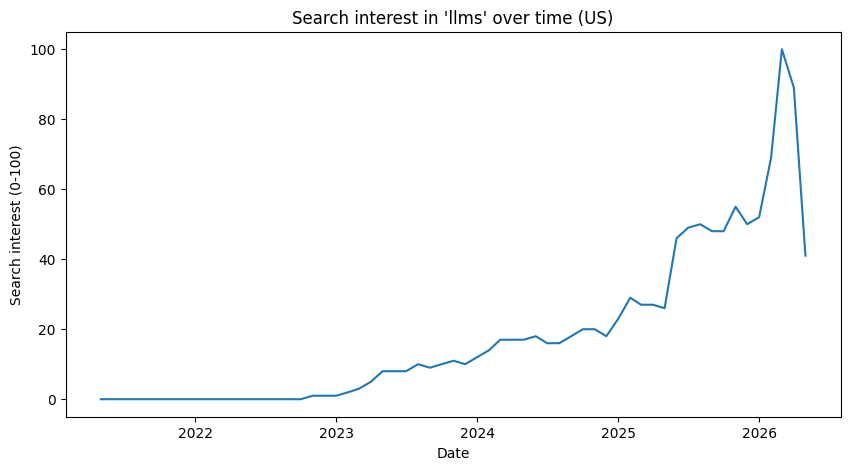

In [7]:
plt.figure(figsize=(10,5))
plt.plot(df['Time'], df['llms'])
plt.title("Search interest in 'llms' over time (US)")
plt.xlabel("Date")
plt.ylabel("Search interest (0-100)")
plt.show()

This is interesting because the line just sits at zero for what looks like over a year, and then suddenly it isn't zero anymore.

Google Trends scales everything from 0 to 100, where 100 is the single highest month in the window. So a zero doesn't actually mean no one searched it, it means it was tiny compared to the peak.

It looks like something happened around the end of 2022 that flipped the switch.

First month with nonzero interest: 2022-11
Value: 1


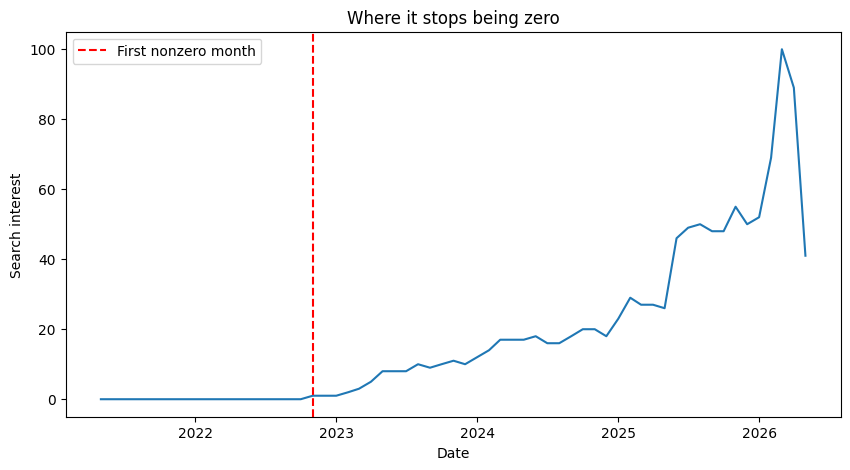

In [8]:
first_nonzero = df[df['llms'] > 0].iloc[0]
print("First month with nonzero interest:", first_nonzero['Time'].strftime('%Y-%m'))
print("Value:", first_nonzero['llms'])

plt.figure(figsize=(10,5))
plt.plot(df['Time'], df['llms'])
plt.axvline(first_nonzero['Time'], color='red', linestyle='--', label='First nonzero month')
plt.title("Where it stops being zero")
plt.xlabel("Date")
plt.ylabel("Search interest")
plt.legend()
plt.show()

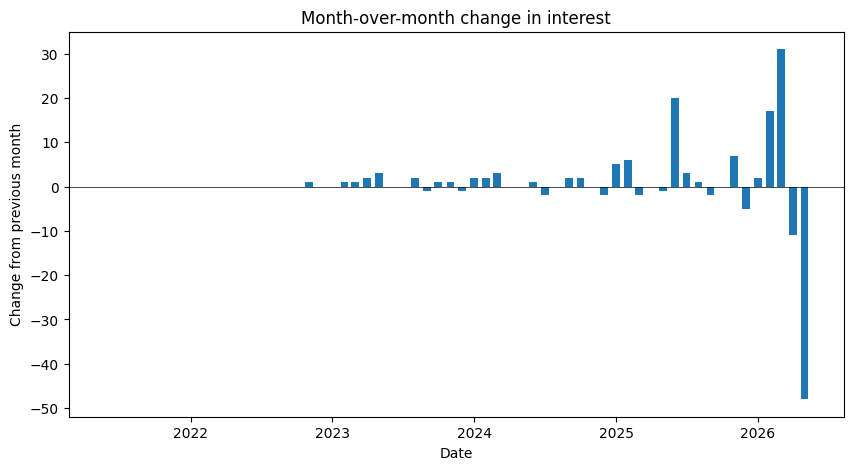

,Time,llms,mom
58,2026-03-01,100,31.0
49,2025-06-01,46,20.0
57,2026-02-01,69,17.0
54,2025-11-01,55,7.0
45,2025-02-01,29,6.0


In [9]:
df['mom'] = df['llms'].diff()

plt.figure(figsize=(10,5))
plt.bar(df['Time'], df['mom'], width=20)
plt.title("Month-over-month change in interest")
plt.xlabel("Date")
plt.ylabel("Change from previous month")
plt.axhline(0, color='black', linewidth=0.5)
plt.show()

df.nlargest(5, 'mom')[['Time','llms','mom']]

Evidentally the growth is not smooth, theres a few months that just jump way higher than the rest. The biggest jumps cluster in 2025 and early 2026.

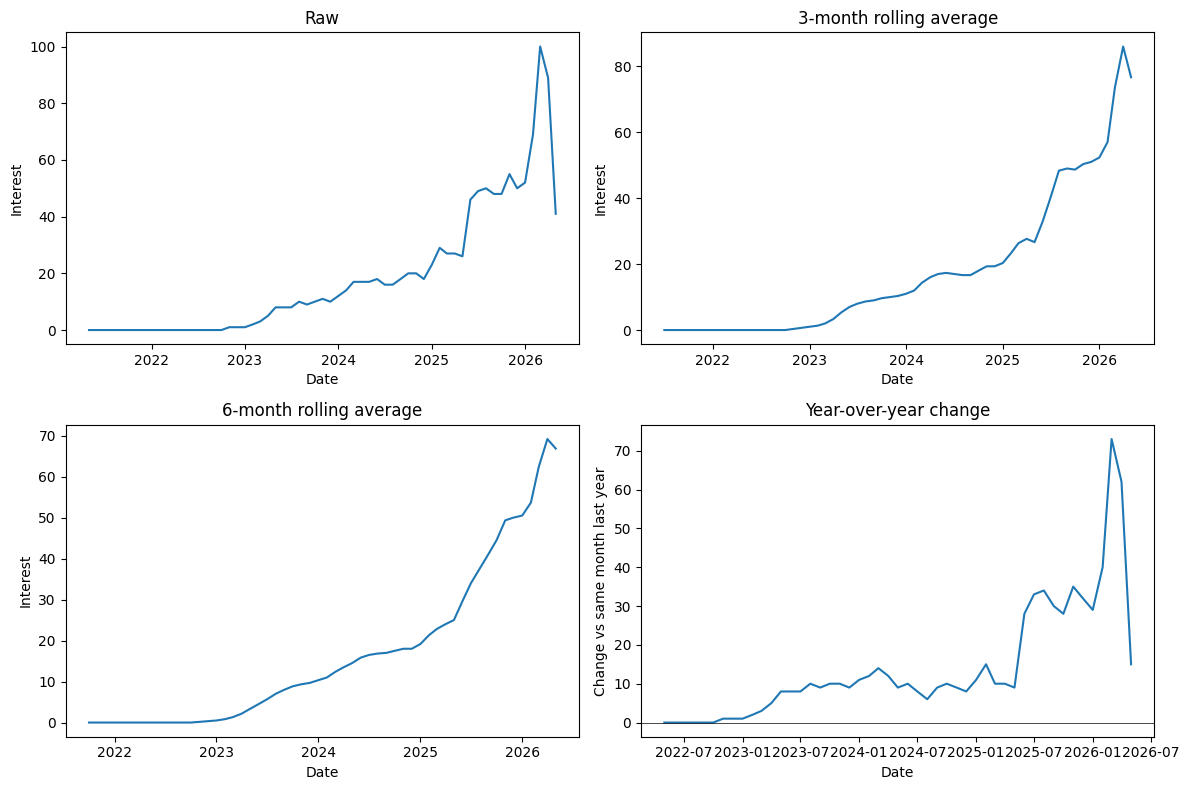

In [10]:
import matplotlib.pyplot as plt

df['r3'] = df['llms'].rolling(3).mean()
df['r6'] = df['llms'].rolling(6).mean()
df['yoy'] = df['llms'].diff(12)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(df['Time'], df['llms'])
plt.title("Raw")
plt.xlabel("Date")
plt.ylabel("Interest")

plt.subplot(2,2,2)
plt.plot(df['Time'], df['r3'])
plt.title("3-month rolling average")
plt.xlabel("Date")
plt.ylabel("Interest")

plt.subplot(2,2,3)
plt.plot(df['Time'], df['r6'])
plt.title("6-month rolling average")
plt.xlabel("Date")
plt.ylabel("Interest")

plt.subplot(2,2,4)
plt.plot(df['Time'], df['yoy'])
plt.title("Year-over-year change")
plt.xlabel("Date")
plt.ylabel("Change vs same month last year")
plt.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

Smoothing it out makes the underlying shape way clearer. The 6-month average basically never goes down, it just keeps climbing. The year-over-year plot also stays positive the whole time which means every month was bigger than the same month a year before.

If every month is beating last year's month, then maybe its easier to just compare whole years against each other instead of looking at all 61 points at once.

Lets break it out by year and see how each year stacks up.

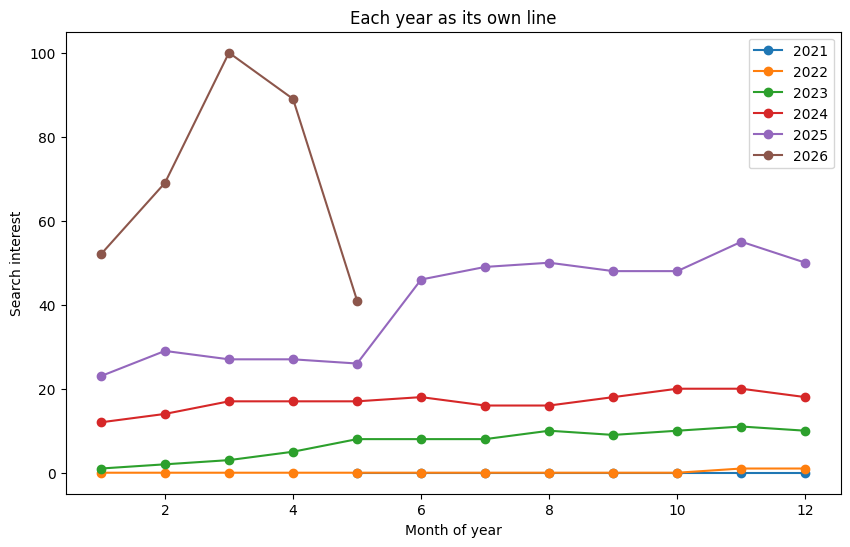

year,2021,2022,2023,2024,2025,2026
month,,,,,,
1,NaN,0.0,1.0,12.0,23.0,52.0
2,NaN,0.0,2.0,14.0,29.0,69.0
3,NaN,0.0,3.0,17.0,27.0,100.0
4,NaN,0.0,5.0,17.0,27.0,89.0
5,0.0,0.0,8.0,17.0,26.0,41.0
6,0.0,0.0,8.0,18.0,46.0,NaN
7,0.0,0.0,8.0,16.0,49.0,NaN
8,0.0,0.0,10.0,16.0,50.0,NaN
9,0.0,0.0,9.0,18.0,48.0,NaN


In [11]:
df['year'] = df['Time'].dt.year
df['month'] = df['Time'].dt.month

pivot = df.pivot_table(index='month', columns='year', values='llms')

plt.figure(figsize=(10,6))
for year in pivot.columns:
    plt.plot(pivot.index, pivot[year], marker='o', label=str(year))
plt.title("Each year as its own line")
plt.xlabel("Month of year")
plt.ylabel("Search interest")
plt.legend()
plt.show()

pivot

What is noteworthy here is that the lines for each year sit on top of each other in order, no year ever dips below the year before it for the same month. Also, 2026 only has 5 months of data so its line cuts off in May. We should keep that in mind when comparing it to full years.

In [12]:
yearly_mean = df.groupby('year')['llms'].mean()
yearly_max = df.groupby('year')['llms'].max()

print("Average interest per year:")
print(yearly_mean.round(1))
print()
print("Peak interest per year:")
print(yearly_max)

Average interest per year:
year
2021     0.0
2022     0.2
2023     7.1
2024    16.9
2025    39.8
2026    70.2
Name: llms, dtype: float64

Peak interest per year:
year
2021      0
2022      1
2023     11
2024     20
2025     55
2026    100
Name: llms, dtype: int64


This is easier to compare than the noisy monthly data!

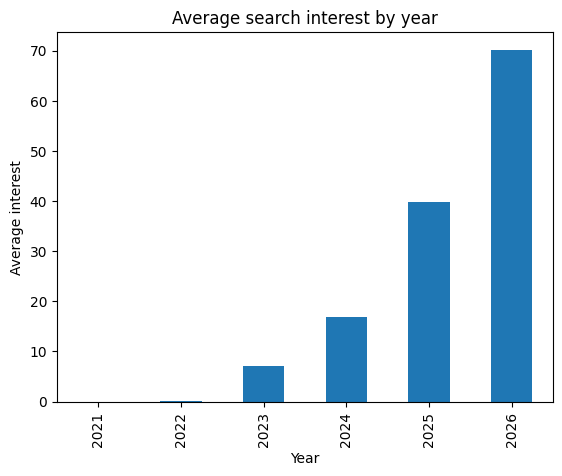

In [13]:
yearly_mean.plot(kind='bar')
plt.title("Average search interest by year")
plt.xlabel("Year")
plt.ylabel("Average interest")
plt.show()

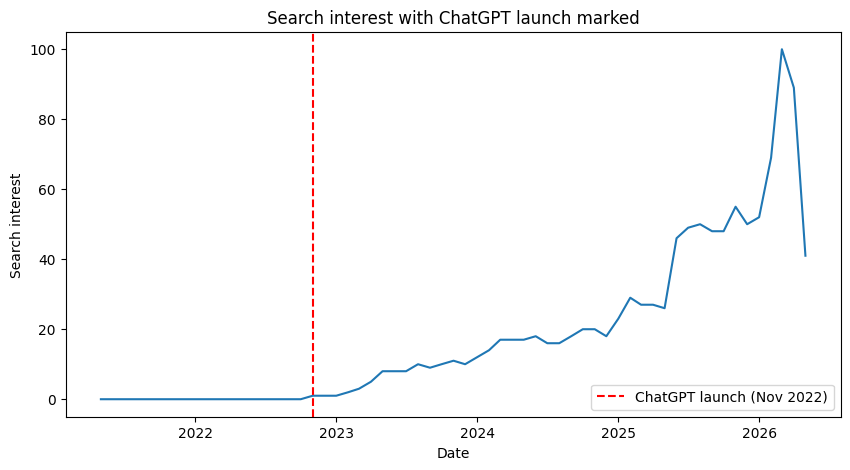

In [14]:
launch = pd.Timestamp('2022-11-01')

plt.figure(figsize=(10,5))
plt.plot(df['Time'], df['llms'])
plt.axvline(launch, color='red', linestyle='--', label='ChatGPT launch (Nov 2022)')
plt.title("Search interest with ChatGPT launch marked")
plt.xlabel("Date")
plt.ylabel("Search interest")
plt.legend()
plt.show()

This is super interesting! Evidentally the term "llms" basically didn't exist as a search until ChatGPT came out at the end of 2022, and then it climbed for three straight years before hitting 100 in March 2026.

The other thing that stands out is the last point, May 2026 only shows 41 which is way below the March peak of 100. That could mean interest is actually cooling off, or it could just be that May 2026 is the current month and Google Trends doesn't have the full month of data yet so it looks smaller than it really is.

Either way, going from zero to dominating the search index in about three years is a pretty wild trajectory for one term.